# Day 5 Evaluation and Text Context

Day 5 evaluates the frozen Day 4 holdout outputs and adds BBC headline sentiment as qualitative context. It does not retrain, tune, or change the Day 4 model.

Core rule: the Day 4 holdout set is closed. Metrics measure out-of-sample generalisation only, not causal truth.


## 00_setup

This setup cell defines paths, imports the Day 5 evaluation helper, and keeps plotting reproducible in notebooks and scripts.


In [1]:
from pathlib import Path
import shutil
import sys

import matplotlib
from IPython import get_ipython
from IPython.display import Image, display
import pandas as pd

ip = get_ipython()
if ip is None:
    matplotlib.use("Agg")
else:
    ip.run_line_magic("matplotlib", "inline")

project_root = Path.cwd()
if project_root.name == "notebooks":
    project_root = project_root.parent

sys.path.append(str(project_root))

outputs_dir = project_root / "outputs"
raw_dir = project_root / "data" / "raw"
processed_dir = project_root / "data" / "processed"
figures_dir = project_root / "figures" / "day5"

outputs_dir.mkdir(exist_ok=True)
raw_dir.mkdir(parents=True, exist_ok=True)
processed_dir.mkdir(parents=True, exist_ok=True)
figures_dir.mkdir(parents=True, exist_ok=True)

from src.day5_eval_model import (
    HOLDOUT_PATH,
    DAY5_METRICS_PATH,
    DAY5_OFFICIAL_METRICS_PATH,
    DAY5_RESIDUALS_PATH,
    DAY5_RESIDUAL_PLOT_PATH,
    DAY5_SENTIMENT_PLOT_PATH,
    compute_holdout_metrics,
    load_frozen_holdout,
    run_evaluation,
    save_sentiment_plot,
)

print("Project root:", project_root)
print("Frozen Day 4 holdout:", HOLDOUT_PATH)


Project root: /Users/hongmiaozhu/PycharmProjects/Project 
Frozen Day 4 holdout: /Users/hongmiaozhu/PycharmProjects/Project /outputs/day4_model_comparison_holdout_predictions.csv


Interpretation note: setup is intentionally boring and traceable. A reproducible evaluation notebook should make file locations obvious before any results are interpreted.


## 01_load_day4_outputs

This section loads the frozen Day 4 holdout prediction file. These predictions were produced during Day 4 and are not regenerated here.


In [2]:
holdout = load_frozen_holdout()

print("Holdout rows:", len(holdout))
print("Holdout date range:", holdout["year_month"].min().strftime("%Y-%m"), "to", holdout["year_month"].max().strftime("%Y-%m"))
print("Columns:", holdout.columns.tolist())

display(holdout.head())


Holdout rows: 12
Holdout date range: 2025-02 to 2026-01
Columns: ['year_month', 'actual_house_price_index', 'linear_predicted', 'random_forest_predicted']


,year_month,actual_house_price_index,linear_predicted,random_forest_predicted
0,2025-02-01,101.4,98.489588,99.237028
1,2025-03-01,102.8,98.049268,99.327149
2,2025-04-01,99.9,97.530650,101.221255
3,2025-05-01,101.3,97.114246,99.136880
4,2025-06-01,102.5,97.110893,99.131730


Interpretation note: the holdout period is the most recent chronological test window from Day 4. It is used for evaluation only, not for feature selection or tuning.


## 02_compute_official_holdout_metrics

This section computes the official Day 5 metrics from the frozen Day 4 holdout predictions. It compares the Linear Regression baseline against the Random Forest comparison model when both predictions are available.


In [3]:
metrics = compute_holdout_metrics(holdout)

metrics.to_csv(outputs_dir / "day5_metrics.csv", index=False)
metrics.to_csv(outputs_dir / "day5_official_holdout_metrics.csv", index=False)

print("Official Day 5 holdout metrics:")
display(metrics)

print("Saved canonical metrics to:", outputs_dir / "day5_metrics.csv")
print("Saved compatibility metrics to:", outputs_dir / "day5_official_holdout_metrics.csv")


Official Day 5 holdout metrics:


,model,role,evaluation_set,target,holdout_rows,MAE,RMSE,R2,notes,MAE_improvement_vs_baseline,RMSE_improvement_vs_baseline,R2_change_vs_baseline
0,linear_regression,baseline,closed_day4_holdout,house_price_index,12,6.377,6.783,-28.506,Frozen Day 4 holdout. Metrics measure generali...,0.000,0.000,0.00
1,random_forest,comparison,closed_day4_holdout,house_price_index,12,3.371,3.616,-7.386,Frozen Day 4 holdout. Metrics measure generali...,3.006,3.167,21.12


Saved canonical metrics to: /Users/hongmiaozhu/PycharmProjects/Project /outputs/day5_metrics.csv
Saved compatibility metrics to: /Users/hongmiaozhu/PycharmProjects/Project /outputs/day5_official_holdout_metrics.csv


Interpretation note: MAE and RMSE are in house-price-index points. Negative holdout R2 means the model is not yet a strong predictive tool compared with a simple mean benchmark. The Random Forest may be less wrong than the baseline, but that does not make it a strong forecasting model.


## 03_residual_diagnostics_and_error_interpretation

Residuals make model errors visible month by month. The residual is defined as `y_pred - y_true`, so negative values mean the model under-predicted the house price index.


Day 5 evaluation complete.
- Metrics: /Users/hongmiaozhu/PycharmProjects/Project /outputs/day5_metrics.csv
- Official metrics compatibility copy: /Users/hongmiaozhu/PycharmProjects/Project /outputs/day5_official_holdout_metrics.csv
- Residuals: /Users/hongmiaozhu/PycharmProjects/Project /outputs/day5_residuals.csv
- Residual diagnostic plot: /Users/hongmiaozhu/PycharmProjects/Project /outputs/day5_residual_diagnostic.png
- Sentiment plot: /Users/hongmiaozhu/PycharmProjects/Project /outputs/day5_sentiment.png
- Canonical BBC raw corpus: /Users/hongmiaozhu/PycharmProjects/Project /data/raw/bbc_headlines.csv
Interpretation note: negative holdout R2 means these models are weak predictive tools.
Weak holdout R2 models: linear_regression, random_forest
Residual rows: 24


,year_month,model,model_role,target,y_true,y_pred,residual,absolute_error,quarter
0,2025-02-01,linear_regression,baseline,house_price_index,101.4,98.489588,-2.910412,2.910412,2025Q1
1,2025-03-01,linear_regression,baseline,house_price_index,102.8,98.049268,-4.750732,4.750732,2025Q1
2,2025-04-01,linear_regression,baseline,house_price_index,99.9,97.530650,-2.369350,2.369350,2025Q2
3,2025-05-01,linear_regression,baseline,house_price_index,101.3,97.114246,-4.185754,4.185754,2025Q2
4,2025-06-01,linear_regression,baseline,house_price_index,102.5,97.110893,-5.389107,5.389107,2025Q2


Residual file: /Users/hongmiaozhu/PycharmProjects/Project /outputs/day5_residuals.csv
Residual diagnostic plot: /Users/hongmiaozhu/PycharmProjects/Project /outputs/day5_residual_diagnostic.png


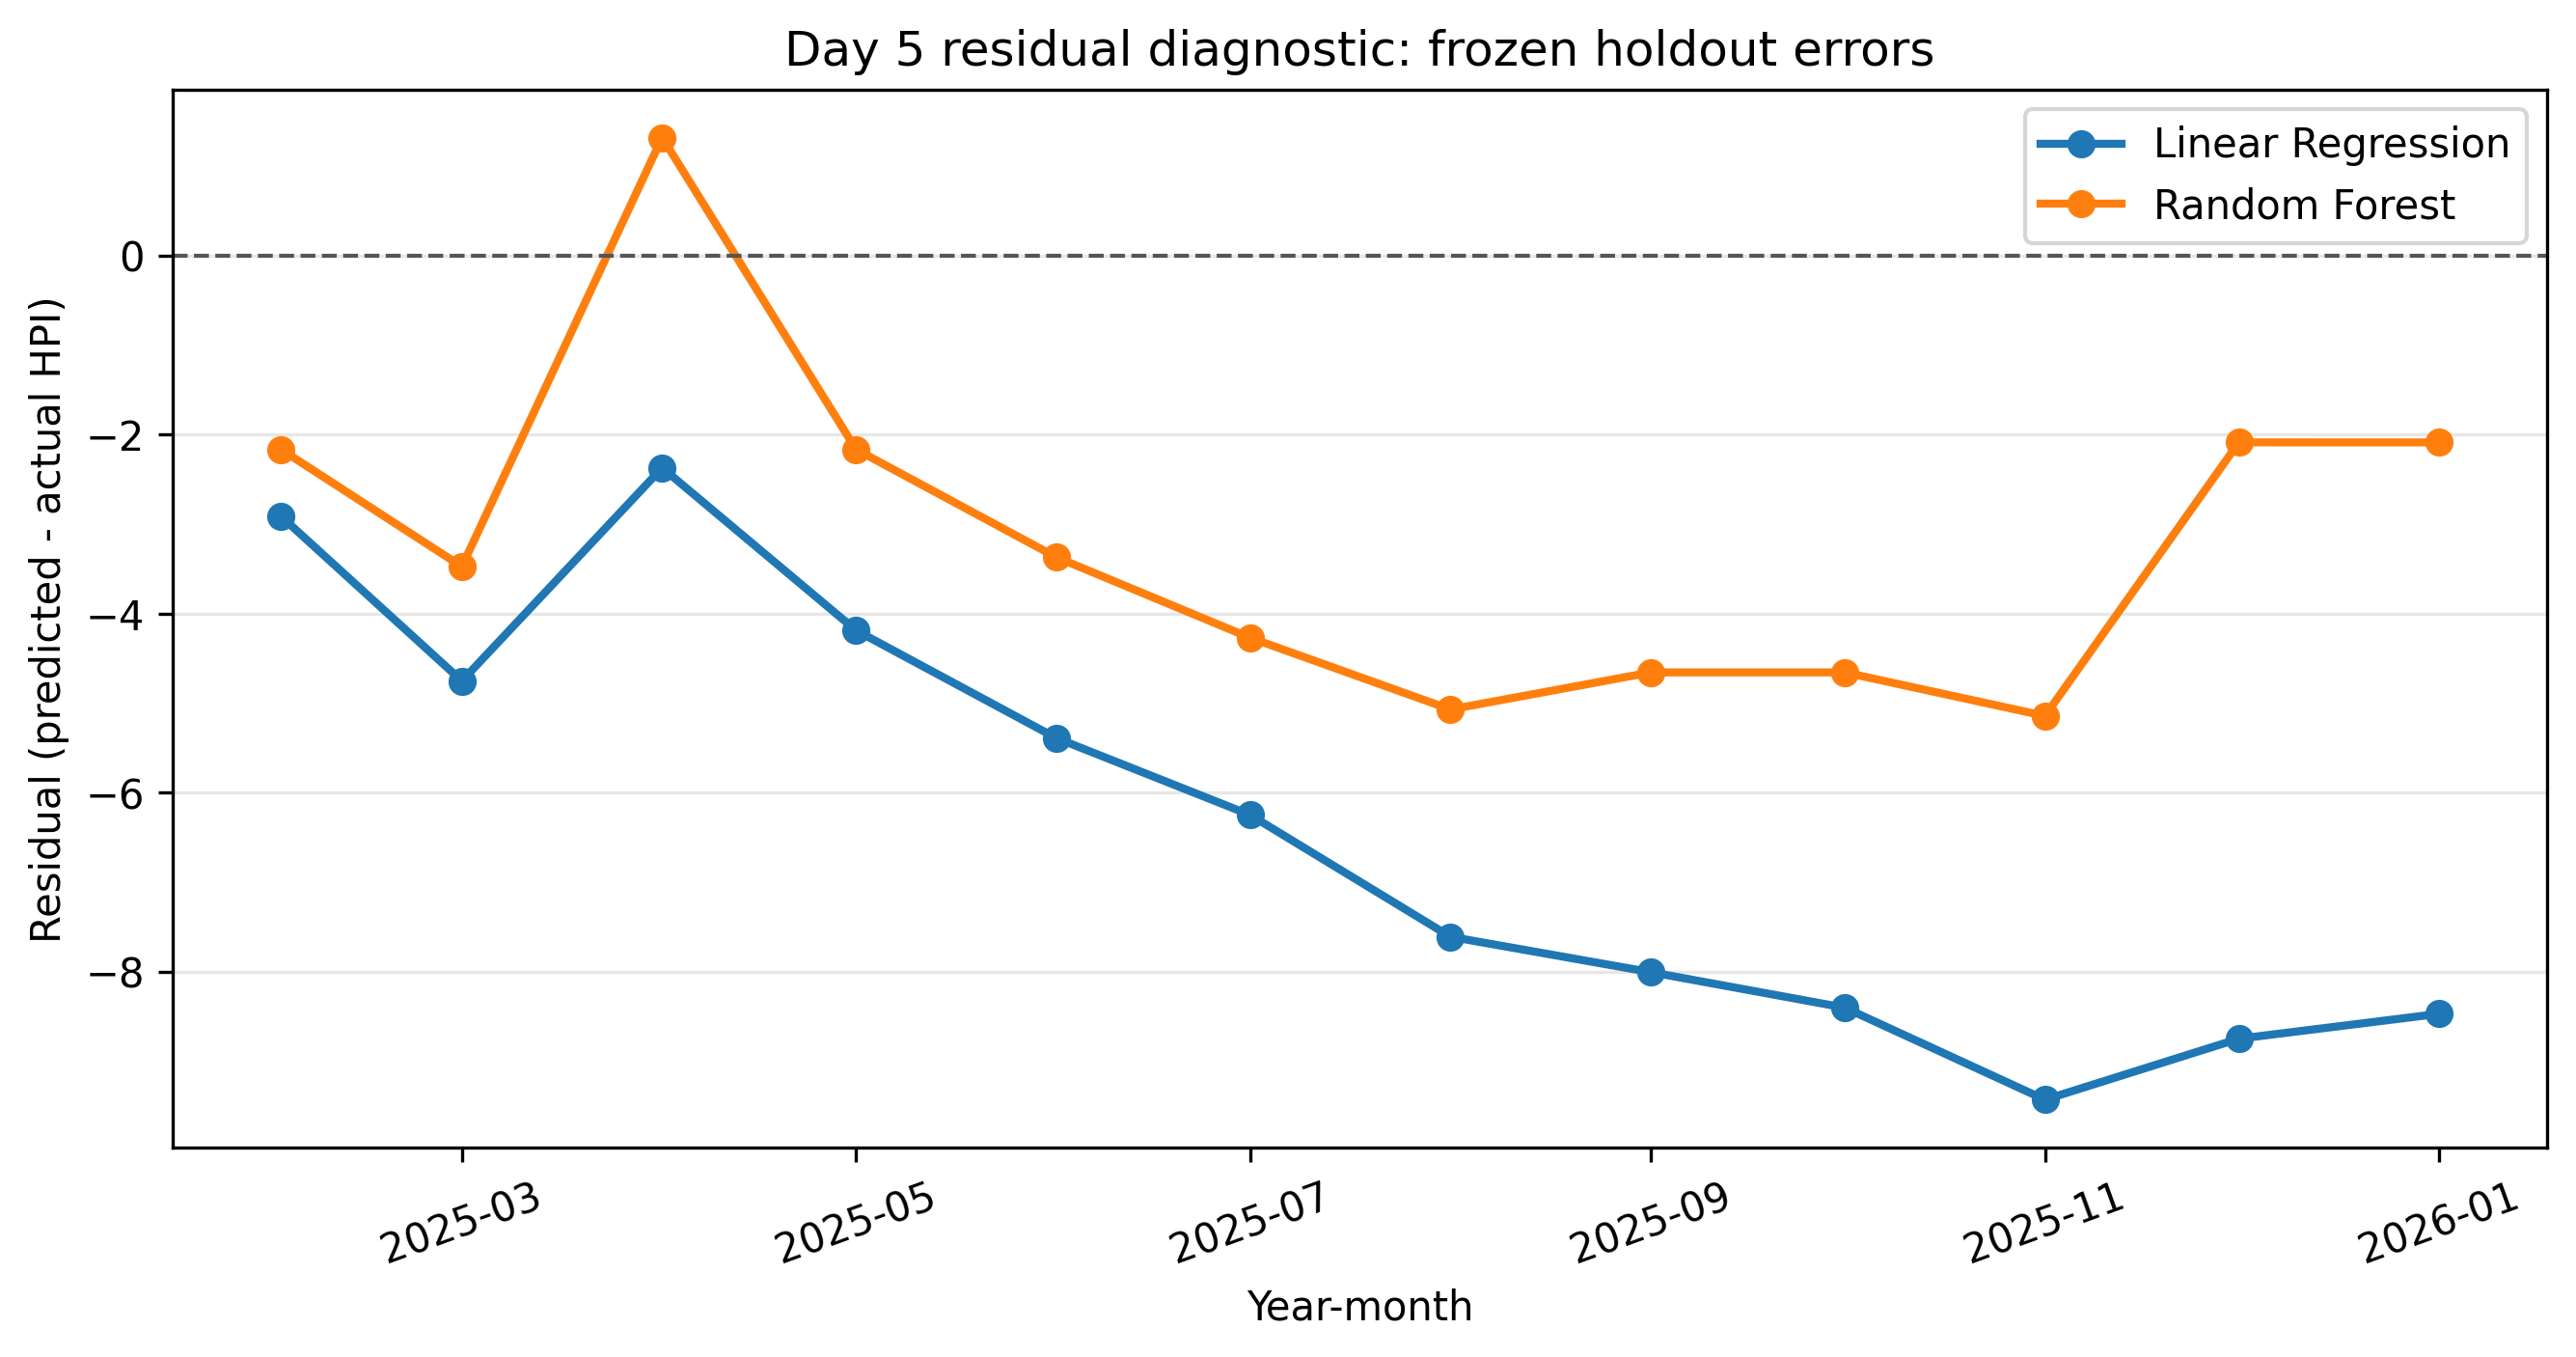

In [4]:
# run_evaluation saves metrics, residuals, and diagnostic plots without retraining Day 4.
metrics, residuals = run_evaluation()

print("Residual rows:", len(residuals))
display(residuals.head())

print("Residual file:", DAY5_RESIDUALS_PATH)
print("Residual diagnostic plot:", DAY5_RESIDUAL_PLOT_PATH)

display(Image(filename=str(DAY5_RESIDUAL_PLOT_PATH)))


Interpretation note: residual diagnostics are descriptive. They show where prediction errors occur, but they do not prove why those errors happened.


## 04_bbc_corpus_collection_description

The BBC headline corpus provides qualitative media context for the cost-of-living and housing story. The current project keeps the collected corpus as a raw file so the text evidence remains auditable.

For this submission pass, the notebook uses the existing collected BBC corpus rather than scraping again. This preserves reproducibility and avoids changing the evidence base during evaluation.


In [5]:
legacy_bbc_raw = outputs_dir / "day5_bbc_headline_corpus_raw.csv"
canonical_bbc_raw = raw_dir / "bbc_headlines.csv"

if not legacy_bbc_raw.exists():
    raise FileNotFoundError("Missing BBC raw corpus. Expected outputs/day5_bbc_headline_corpus_raw.csv")

shutil.copy2(legacy_bbc_raw, canonical_bbc_raw)
bbc_raw = pd.read_csv(canonical_bbc_raw)

print("Canonical raw BBC corpus:", canonical_bbc_raw)
print("Raw headline rows:", len(bbc_raw))
print("Columns:", bbc_raw.columns.tolist())
display(bbc_raw.head())


Canonical raw BBC corpus: /Users/hongmiaozhu/PycharmProjects/Project /data/raw/bbc_headlines.csv
Raw headline rows: 50
Columns: ['source', 'language', 'search_term', 'title', 'date_published', 'url', 'description', 'retrieval_method', 'borderline_note']


,source,language,search_term,title,date_published,url,description,retrieval_method,borderline_note
0,BBC News,English,"""house prices""",Oil prices plunge as Iran says Strait of Hormu...,2026-04-17,https://www.bbc.co.uk/news/articles/ckg045z73z1o,Brent crude sinks by a tenth after Iran says t...,BBC search page embedded JSON,NaN
1,BBC News,English,cost of living,Scottish Lib Dems vow NHS and cost of living a...,2026-04-17,https://www.bbc.co.uk/news/articles/c4gj01zx75qo,Scottish leader Alex Cole-Hamilton has announc...,BBC search page embedded JSON,Borderline: policy or political framing rather...
2,BBC News,English,wages,Noida protests: Workers in India demand hike i...,2026-04-16,https://www.bbc.co.uk/news/articles/ce8444gex65o,Workers in some north Indian cities have been ...,BBC search page embedded JSON,NaN
3,BBC News,English,"""food prices""",Retailers criticise SNP's 'gimmick' food price...,2026-04-16,https://www.bbc.co.uk/news/articles/cx2r19v82z8o,"John Swinney said it was a ""moral outrage"" tha...",BBC search page embedded JSON,NaN
4,BBC News,English,rent,Green Leader Zack Polanski calls for rent cont...,2026-04-16,https://www.bbc.co.uk/news/articles/cql77nrgv67o,Limiting how much landlords can increase rents...,BBC search page embedded JSON,NaN


Interpretation note: BBC headlines are used as public-discourse context. They are not a direct welfare measure and cannot prove household financial conditions.


## 05_cleaning_and_deduplication_of_headlines

This section applies light, transparent cleaning: remove empty titles, trim whitespace, standardise dates, and drop exact duplicate titles/URLs. No manual hidden cleaning is used.


In [6]:
bbc_clean = bbc_raw.copy()

bbc_clean["title"] = bbc_clean["title"].astype(str).str.strip()
bbc_clean["date_published"] = pd.to_datetime(bbc_clean["date_published"], errors="coerce").dt.strftime("%Y-%m-%d")

before_rows = len(bbc_clean)
bbc_clean = bbc_clean[bbc_clean["title"].ne("")].copy()
subset_cols = [col for col in ["title", "url"] if col in bbc_clean.columns]
bbc_clean = bbc_clean.drop_duplicates(subset=subset_cols).reset_index(drop=True)
after_rows = len(bbc_clean)

print("Rows before cleaning:", before_rows)
print("Rows after cleaning:", after_rows)
print("Duplicates or empty-title rows removed:", before_rows - after_rows)
display(bbc_clean.head())


Rows before cleaning: 50
Rows after cleaning: 50
Duplicates or empty-title rows removed: 0


,source,language,search_term,title,date_published,url,description,retrieval_method,borderline_note
0,BBC News,English,"""house prices""",Oil prices plunge as Iran says Strait of Hormu...,2026-04-17,https://www.bbc.co.uk/news/articles/ckg045z73z1o,Brent crude sinks by a tenth after Iran says t...,BBC search page embedded JSON,NaN
1,BBC News,English,cost of living,Scottish Lib Dems vow NHS and cost of living a...,2026-04-17,https://www.bbc.co.uk/news/articles/c4gj01zx75qo,Scottish leader Alex Cole-Hamilton has announc...,BBC search page embedded JSON,Borderline: policy or political framing rather...
2,BBC News,English,wages,Noida protests: Workers in India demand hike i...,2026-04-16,https://www.bbc.co.uk/news/articles/ce8444gex65o,Workers in some north Indian cities have been ...,BBC search page embedded JSON,NaN
3,BBC News,English,"""food prices""",Retailers criticise SNP's 'gimmick' food price...,2026-04-16,https://www.bbc.co.uk/news/articles/cx2r19v82z8o,"John Swinney said it was a ""moral outrage"" tha...",BBC search page embedded JSON,NaN
4,BBC News,English,rent,Green Leader Zack Polanski calls for rent cont...,2026-04-16,https://www.bbc.co.uk/news/articles/cql77nrgv67o,Limiting how much landlords can increase rents...,BBC search page embedded JSON,NaN


Interpretation note: deduplication keeps the sentiment summary from over-counting repeated headlines. It does not make the corpus statistically representative of all UK media.


## 06_sentiment_scoring

This section scores each headline with VADER, a simple rule-based sentiment tool for short text. The score is used as qualitative context only.


In [7]:
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

analyzer = SentimentIntensityAnalyzer()

def assign_vader_label(score):
    if score >= 0.05:
        return "positive"
    if score <= -0.05:
        return "negative"
    return "neutral"

bbc_sentiment = bbc_clean.copy()
bbc_sentiment["vader_compound"] = bbc_sentiment["title"].apply(lambda text: analyzer.polarity_scores(str(text))["compound"])
bbc_sentiment["vader_label"] = bbc_sentiment["vader_compound"].apply(assign_vader_label)

sentiment_out = processed_dir / "bbc_sentiment.csv"
bbc_sentiment.to_csv(sentiment_out, index=False)

# Preserve the existing Day 5 feature-output naming as well.
bbc_sentiment.to_csv(outputs_dir / "day5_bbc_headline_sentiment_features.csv", index=False)
monthly_sentiment = (
    bbc_sentiment.assign(month=pd.to_datetime(bbc_sentiment["date_published"], errors="coerce").dt.strftime("%Y-%m"))
    .dropna(subset=["month"])
    .groupby(["month", "search_term"], as_index=False)
    .agg(
        headline_count=("title", "size"),
        avg_vader_compound=("vader_compound", "mean"),
        negative_count=("vader_label", lambda s: int((s == "negative").sum())),
        neutral_count=("vader_label", lambda s: int((s == "neutral").sum())),
        positive_count=("vader_label", lambda s: int((s == "positive").sum())),
    )
)
monthly_sentiment.to_csv(outputs_dir / "day5_bbc_monthly_sentiment_features.csv", index=False)

print("Sentiment distribution:")
print(bbc_sentiment["vader_label"].value_counts().to_string())
print("Saved processed sentiment to:", sentiment_out)
display(bbc_sentiment[["title", "date_published", "search_term", "vader_compound", "vader_label"]].head())


Sentiment distribution:
vader_label
negative    23
neutral     14
positive    13
Saved processed sentiment to: /Users/hongmiaozhu/PycharmProjects/Project /data/processed/bbc_sentiment.csv


,title,date_published,search_term,vader_compound,vader_label
0,Oil prices plunge as Iran says Strait of Hormu...,2026-04-17,"""house prices""",0.0000,neutral
1,Scottish Lib Dems vow NHS and cost of living a...,2026-04-17,cost of living,0.0000,neutral
2,Noida protests: Workers in India demand hike i...,2026-04-16,wages,-0.1779,negative
3,Retailers criticise SNP's 'gimmick' food price...,2026-04-16,"""food prices""",-0.1531,negative
4,Green Leader Zack Polanski calls for rent cont...,2026-04-16,rent,0.0000,neutral


Interpretation note: negative sentiment means the wording of a headline is negative. It does not automatically mean household welfare worsened, and it does not establish causality.


## 07_sentiment_visual_summary

This section creates a simple presentation-ready chart of BBC headline sentiment counts.


Saved sentiment chart to: /Users/hongmiaozhu/PycharmProjects/Project /outputs/day5_sentiment.png


,headline_count,count
0,negative,23
1,neutral,14
2,positive,13


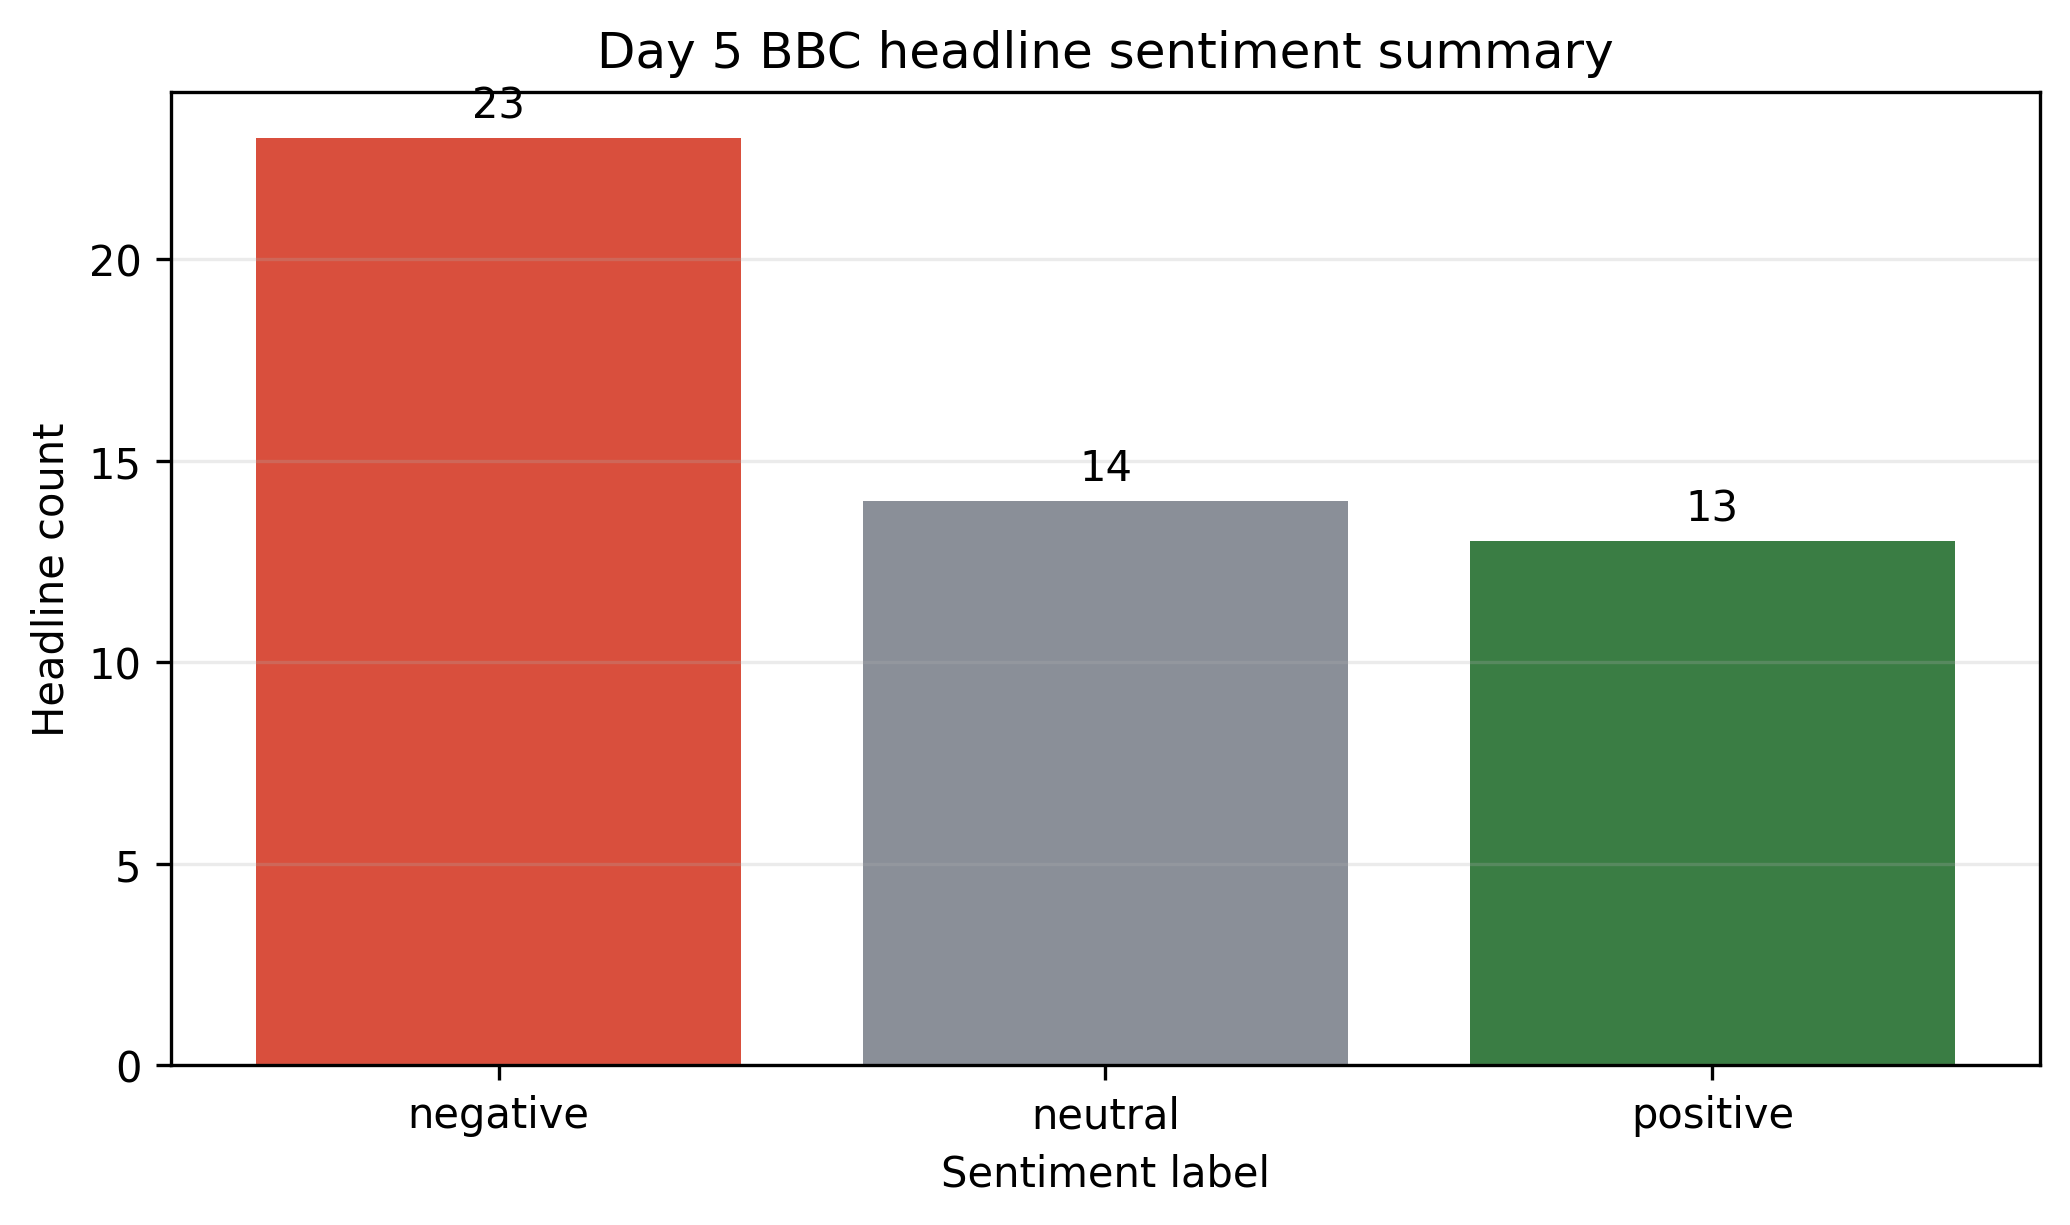

In [8]:
sentiment_counts = save_sentiment_plot()

print("Saved sentiment chart to:", DAY5_SENTIMENT_PLOT_PATH)
if sentiment_counts is not None:
    display(sentiment_counts)

display(Image(filename=str(DAY5_SENTIMENT_PLOT_PATH)))


Interpretation note: the sentiment chart complements the model evaluation by showing media framing. It should be read beside the quantitative evidence, not as proof of economic impact.


## 08_day6_handoff

Day 6 can now use the model evaluation outputs and sentiment context without changing the Day 4 model.

Files handed forward:
- `outputs/day5_metrics.csv`
- `outputs/day5_official_holdout_metrics.csv`
- `outputs/day5_residuals.csv`
- `outputs/day5_residual_diagnostic.png`
- `outputs/day5_sentiment.png`
- `data/raw/bbc_headlines.csv`
- `data/processed/bbc_sentiment.csv`

Interpretation note: Day 5 shows that the modelling pipeline is reproducible but predictive performance remains weak. The sentiment material adds context for public concern, while Day 6 should keep the causal and distributional limits explicit.
